# Week 6 - Decision Trees and Random Forests

The final modeling week applies tree-based classifiers to both binary targets:

* Dataset A - Credit card: `is_fraud`.
* Dataset B - UNSW-NB15: `label`

A decision tree splits the data with yes/no questions and overfits if grown too deep. A
random forest averages many de-correlated trees to cut that variance. Trees need no feature
scaling. I treat the random forest in depth on the UNSW data
because it is the best-performing model on the realistic problem. Its tuning, overfitting
control, and feature importance all connect directly to the network-security question.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
RNG = 42

cc = pd.read_csv("data/credit_card_fraud_dataset.csv")
cc["log_amount"] = np.log1p(cc["transaction_amount_usd"])
cc_continuous = ["credit_utilization_pct", "avg_monthly_spend_usd", "annual_income_usd",
                 "credit_limit_usd", "distance_from_home_km", "num_transactions_last_30d",
                 "age", "credit_score", "account_age_months", "velocity_last_1h"]
cc_binary = ["is_international_transaction", "is_new_merchant", "is_night_transaction",
             "card_present", "cvv_mismatch", "device_changed"]
cc_categorical = ["merchant_category", "device_type", "occupation"]
cc_clf_feats = ["cvv_mismatch", "prev_fraud_flags", "failed_attempts_last_24h", "device_changed",
                "is_international_transaction", "is_new_merchant", "card_present",
                "is_night_transaction", "velocity_last_1h", "credit_utilization_pct",
                "transaction_amount_usd", "distance_from_home_km", "num_transactions_last_30d",
                "age", "credit_score"]

def cc_regression_design():
    X = pd.concat([
        cc[cc_continuous].reset_index(drop=True),
        cc[cc_binary].reset_index(drop=True).astype(float),
        pd.get_dummies(cc[cc_categorical], drop_first=True).reset_index(drop=True).astype(float),
    ], axis=1)
    return X, cc["log_amount"].values

def cc_classification_design():
    return cc[cc_clf_feats].copy(), cc["is_fraud"].values

unsw_full = pd.read_parquet("data_unsw/UNSW_NB15_training-set.parquet")
unsw = unsw_full.groupby("label", group_keys=False).sample(frac=50000/len(unsw_full), random_state=RNG)
unsw = unsw.reset_index(drop=True)
unsw["log_dur"] = np.log1p(unsw["dur"].clip(lower=0))
_top_proto = unsw["proto"].value_counts().head(6).index
unsw["proto_grp"] = np.where(unsw["proto"].isin(_top_proto), unsw["proto"].astype(str), "other")
unsw_cats = ["service", "state", "proto_grp"]
unsw_numeric = [c for c in unsw.select_dtypes(include=[np.number]).columns
                if c not in ("label", "dur", "log_dur")]

def _unsw_dummies():
    return pd.get_dummies(unsw[unsw_cats].astype(str), drop_first=True).reset_index(drop=True).astype(float)

def unsw_regression_design():
    X = pd.concat([unsw[unsw_numeric].reset_index(drop=True), _unsw_dummies()], axis=1)
    return X, unsw["log_dur"].values

def unsw_classification_design():
    num = [c for c in unsw.select_dtypes(include=[np.number]).columns if c not in ("label", "log_dur")]
    X = pd.concat([unsw[num].reset_index(drop=True), _unsw_dummies()], axis=1)
    return X, unsw["label"].values

print("Credit card:", cc.shape, "| fraud rate", round(cc.is_fraud.mean(), 3))
print("UNSW sample:", unsw.shape, "| attack rate", round(unsw.label.mean(), 3))


Credit card: (55000, 30) | fraud rate 0.038
UNSW sample: (50000, 38) | attack rate 0.681


In [2]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from scipy.stats import randint

def depth_curve(X, y, ax, title):
    Xtr, Xte, ytr, yte = train_test_split(X.values, y, test_size=0.25, stratify=y, random_state=RNG)
    depths = [1, 2, 3, 4, 5, 6, 8, 10, 15, 20, None]
    tr, te = [], []
    for d in depths:
        t = DecisionTreeClassifier(max_depth=d, class_weight="balanced", random_state=RNG).fit(Xtr, ytr)
        tr.append(roc_auc_score(ytr, t.predict_proba(Xtr)[:, 1])); te.append(roc_auc_score(yte, t.predict_proba(Xte)[:, 1]))
    xs = [d if d else 25 for d in depths]
    ax.plot(xs, tr, "o-", label="train"); ax.plot(xs, te, "s-", label="test")
    ax.set_xlabel("max_depth (25=unlimited)"); ax.set_ylabel("ROC-AUC"); ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)
    return (Xtr, Xte, ytr, yte)

## Decision-tree depth: overfitting on both datasets

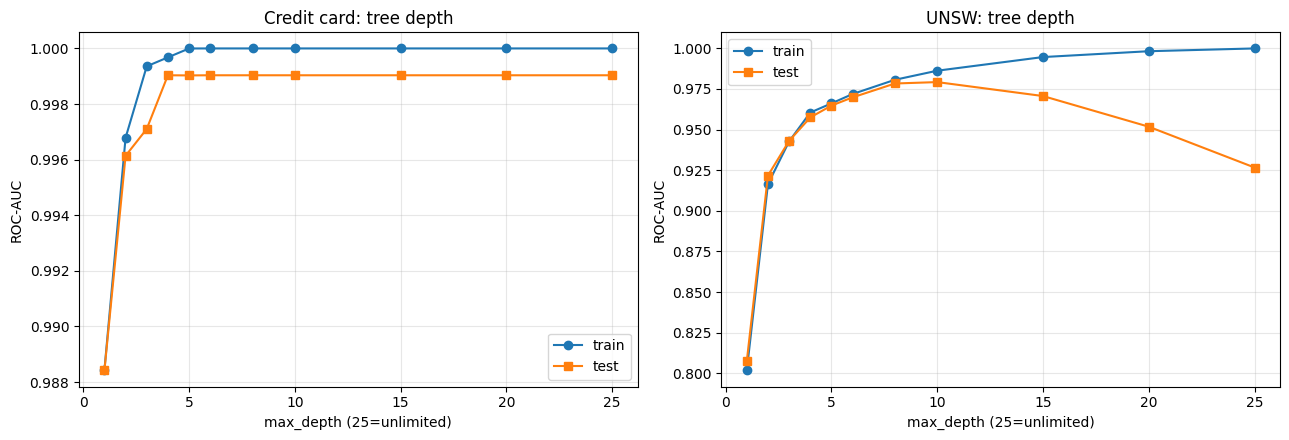

In [3]:
ccX, ccy = cc_classification_design()
uX, uy = unsw_classification_design()
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
cc_data = depth_curve(ccX, ccy, ax[0], "Credit card: tree depth")
u_data = depth_curve(uX, uy, ax[1], "UNSW: tree depth")
plt.tight_layout(); plt.show()

Both curves show the overfitting signature but the gap is far wider for UNSW. On the separable credit-card data even a deep tree
generalizes. On the realistic UNSW data a deep tree clearly
memorizes, opening a visible train/test gap. 

## Random forest in depth - UNSW attack detection

I tune the forest with randomized search and inspect its errors and feature importances.

In [4]:
Xtr, Xte, ytr, yte = u_data
param = {"n_estimators": randint(150, 400), "max_depth": [6, 10, 16, 24, None],
         "min_samples_leaf": randint(1, 12), "max_features": ["sqrt", "log2", 0.5]}
search = RandomizedSearchCV(RandomForestClassifier(class_weight="balanced", n_jobs=-1, random_state=RNG),
                            param, n_iter=15, scoring="roc_auc", cv=3, n_jobs=-1, random_state=RNG).fit(Xtr, ytr)
best = search.best_estimator_
proba = best.predict_proba(Xte)[:, 1]; pred = best.predict(Xte)
print("Best params:", search.best_params_)
print(f"UNSW RF: test ROC-AUC={roc_auc_score(yte, proba):.4f}  F1={f1_score(yte, pred):.4f}")
print(classification_report(yte, pred, target_names=["normal", "attack"], digits=3))

Best params: {'max_depth': 24, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'n_estimators': 378}
UNSW RF: test ROC-AUC=0.9904  F1=0.9586
              precision    recall  f1-score   support

      normal      0.919     0.903     0.911      3992
      attack      0.955     0.963     0.959      8508

    accuracy                          0.943     12500
   macro avg      0.937     0.933     0.935     12500
weighted avg      0.943     0.943     0.943     12500



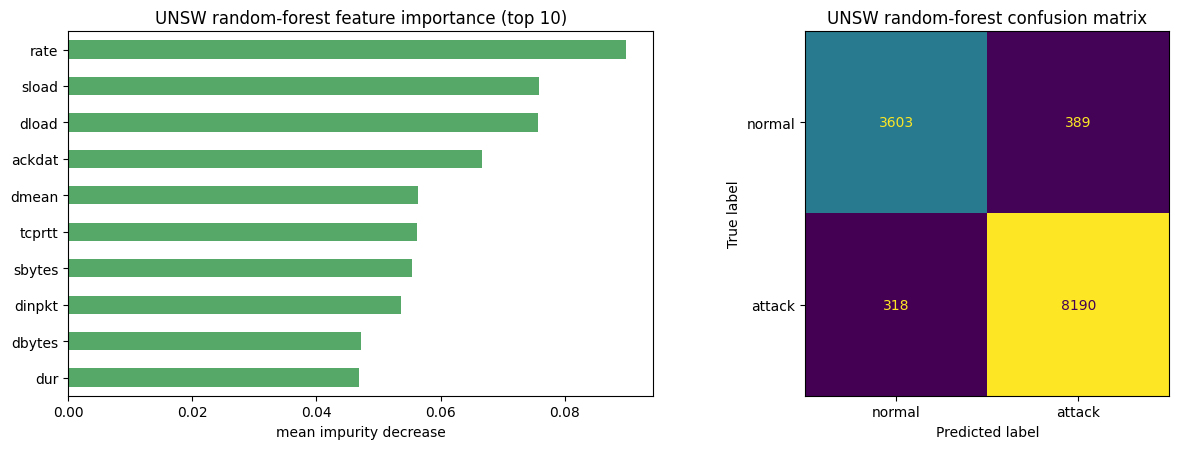

Top UNSW features:
rate      0.090
sload     0.076
dload     0.076
ackdat    0.067
dmean     0.056
dtype: float64


In [5]:
unsw_cols = unsw_classification_design()[0].columns
imp = pd.Series(best.feature_importances_, index=unsw_cols).sort_values().tail(10)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
imp.plot(kind="barh", ax=ax[0], color="#55A868"); ax[0].set_title("UNSW random-forest feature importance (top 10)"); ax[0].set_xlabel("mean impurity decrease")
ConfusionMatrixDisplay(confusion_matrix(yte, pred), display_labels=["normal", "attack"]).plot(ax=ax[1], colorbar=False)
ax[1].set_title("UNSW random-forest confusion matrix")
plt.tight_layout(); plt.show()
print("Top UNSW features:"); print(imp.sort_values(ascending=False).head(5).round(3))

The tuned random forest is the strongest UNSW model in the project with a clearly higher
ROC-AUC and F1 than logistic regression or the SVM, and it overfits far less than a single deep
tree thanks to bagging and feature subsampling. Its top features are network-flow
signals which align with how
real intrusions differ from normal traffic. The confusion matrix shows where it still errs.

## Random forest on the credit-card data

In [6]:
ccXtr, ccXte, ccytr, ccyte = cc_data
cc_rf = RandomForestClassifier(n_estimators=200, max_depth=12, min_samples_leaf=5,
                               class_weight="balanced", n_jobs=-1, random_state=RNG).fit(ccXtr, ccytr)
cc_proba = cc_rf.predict_proba(ccXte)[:, 1]
print(f"Credit-card RF: test ROC-AUC={roc_auc_score(ccyte, cc_proba):.4f}  F1={f1_score(ccyte, cc_rf.predict(ccXte)):.4f}")
cc_imp = pd.Series(cc_rf.feature_importances_, index=cc_classification_design()[0].columns).sort_values(ascending=False)
print("Top credit-card features:"); print(cc_imp.head(5).round(3))

Credit-card RF: test ROC-AUC=1.0000  F1=0.9981
Top credit-card features:
distance_from_home_km       0.361
velocity_last_1h            0.155
failed_attempts_last_24h    0.150
prev_fraud_flags            0.118
transaction_amount_usd      0.076
dtype: float64


On credit card the forest is essentially perfect again and its importances
are led by the deterministic fraud flags and the large distance/amount features.

## Conclusions

* The random forest is the best classifier in the project and on the realistic UNSW problem it
  clearly beats logistic regression and the SVM while overfitting far less than a single deep tree.
* Tree depth visibly drives overfitting and the contrast between datasets is instructive. The
  separable credit-card data barely overfits, the overlapping UNSW data overfits readily, so the
  forest's variance reduction matters most exactly where the problem is hard.
* Feature importance grounds the model in the domain. UNSW attacks are flagged by flow-timing
  and volume features, credit-card fraud by deterministic risk flags.
